# Analysis and Visualization -- KDE Plot and DBSCAN on Tripadvisor Data

In [1]:
import geopandas as gpd
import folium
import seaborn as sns
from sklearn.cluster import DBSCAN
import pandas as pd
import matplotlib.pyplot as plt
import contextily as cx

## read in tripadvisor data

In [2]:
tripadvisor_attractions_df = gpd.read_file('tripadvisor_attractions_geo.geojson')

In [3]:
tripadvisor_attractions_df.head()

,name,link,rating,review_count,category,address,latitude,longitude,geometry
0,Hallgrimskirkja,https://www.tripadvisor.com/Attraction_Review-...,4.4,23266,Churches & Cathedrals,"Hallgrimstorgi 1, Reykjavik 101 Iceland",64.141970,-21.926970,POINT (-21.92697 64.14197)
1,Perlan,https://www.tripadvisor.com/Attraction_Review-...,4.5,4305,Speciality Museums • Points of Interest & Land...,"Öskjuhlíð, Reykjavik 105 Iceland",64.129210,-21.919050,POINT (-21.91905 64.12921)
2,Glacier Lagoon,https://www.tripadvisor.com/Attraction_Review-...,4.9,5082,Bodies of Water,"Skaftafell National Park Route 1, Jokulsarlon ...",64.048550,-16.179256,POINT (-16.17926 64.04855)
3,Gullfoss Falls,https://www.tripadvisor.com/Attraction_Review-...,4.7,12522,Waterfalls,NaN,64.327070,-20.119947,POINT (-20.11995 64.32707)
4,Sky Lagoon,https://www.tripadvisor.com/Attraction_Review-...,4.5,4964,Thermal Spas,"Vesturvör 44-48, Kopavogur 200 Iceland",64.116486,-21.946290,POINT (-21.94629 64.11649)


<Axes: >

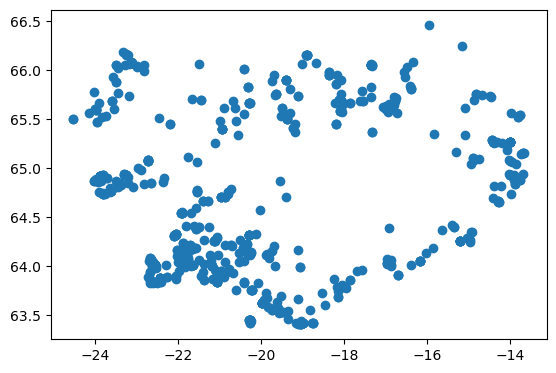

In [4]:
tripadvisor_attractions_df.plot()

## map to get an overview

In [5]:
# Centre map on Iceland
m = folium.Map(location=[64.9, -18.5], zoom_start=6)

for _, row in tripadvisor_attractions_df.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=4,
        fill=True,
        fill_opacity=0.7,
        popup=f"{row['category']}: {row['name']}, {'review counts'}: {row['review_count']}"
    ).add_to(m)

m

## Cleaning the Data Further

### Categories

In [6]:
# categories are currenly stored as strings, need to be converted into list
# this was due to exporting geopandas df

In [7]:
tripadvisor_attractions_df['category'] = tripadvisor_attractions_df['category'].str.split('•').apply(lambda x: [i.strip() for i in x] if isinstance(x, list) else x)

In [8]:
tripadvisor_attractions_df.head(2)

,name,link,rating,review_count,category,address,latitude,longitude,geometry
0,Hallgrimskirkja,https://www.tripadvisor.com/Attraction_Review-...,4.4,23266,[Churches & Cathedrals],"Hallgrimstorgi 1, Reykjavik 101 Iceland",64.14197,-21.92697,POINT (-21.92697 64.14197)
1,Perlan,https://www.tripadvisor.com/Attraction_Review-...,4.5,4305,"[Speciality Museums, Points of Interest & Land...","Öskjuhlíð, Reykjavik 105 Iceland",64.12921,-21.91905,POINT (-21.91905 64.12921)


In [9]:
type(tripadvisor_attractions_df['review_count'][0])

str

In [10]:
# convert review count to integer

tripadvisor_attractions_df['review_count'] = tripadvisor_attractions_df['review_count'].astype(int)

In [11]:
type(tripadvisor_attractions_df['review_count'][0])

numpy.int64

In [12]:
tripadvisor_attractions_df['category'].value_counts()

category
[Speciality & Gift Shops]                           147
[Waterfalls]                                         67
[Geologic Formations]                                46
[Churches & Cathedrals]                              42
[Bars & Clubs]                                       35
                                                   ... 
[Scenic Drives]                                       1
[Historic Sites, Architectural Buildings]             1
[Libraries, Civic Centres]                            1
[Architectural Buildings, Churches & Cathedrals]      1
[Public Transportation Systems]                       1
Name: count, Length: 209, dtype: int64

### Duplicates

It seems that there are some duplicates in the data.

In [13]:
count_geom = tripadvisor_attractions_df['geometry'].nunique()
print(f"There are {count_geom} unique attraction locations.")

There are 938 unique attraction locations.


In [14]:
len(tripadvisor_attractions_df)

1040

In [15]:
duplicates = tripadvisor_attractions_df[tripadvisor_attractions_df.duplicated(subset=['geometry'], keep=False)]
duplicates = duplicates.sort_values(by='geometry')

In [16]:
# duplicates.head(50)

Most of these are actual duplicates. There are a few that have different names. It is safest to filter on duplicate of geometry & name.

In [17]:
tripadvisor_attractions_cleaned_df = tripadvisor_attractions_df.drop_duplicates(subset=['name', 'geometry']).reset_index(drop=True).copy()

In [18]:
len(tripadvisor_attractions_cleaned_df)

955

In [19]:
duplicates_2 = tripadvisor_attractions_cleaned_df[tripadvisor_attractions_cleaned_df.duplicated(subset=['geometry'], keep=False)]
duplicates_2 = duplicates_2.sort_values(by='geometry')

In [20]:
len(duplicates_2)

34

In [21]:
# duplicates_2

In [22]:
# decided to accept this, as scope of this project is limited

In [23]:
tripadvisor_attractions_cleaned_df.tail()

,name,link,rating,review_count,category,address,latitude,longitude,geometry
950,Litla Jolabudin,https://www.tripadvisor.com/Attraction_Review-...,2.8,9,[Speciality & Gift Shops],"Vattarnes Road number 955, Faskrudsfjordur 751...",64.936160,-13.685212,POINT (-13.68521 64.93616)
951,Remember Reykjavík,https://www.tripadvisor.com/Attraction_Review-...,2.3,3,[Speciality & Gift Shops],"Laugavegi 8, Reykjavik 101 Iceland",64.146286,-21.931803,POINT (-21.93180 64.14629)
952,SmaraTivoli,https://www.tripadvisor.com/Attraction_Review-...,2.0,3,[Game & Entertainment Centers],"Laugavegur 32, Reykjavik 101 Iceland",64.145170,-21.927134,POINT (-21.92713 64.14517)
953,Smarabio,https://www.tripadvisor.com/Attraction_Review-...,1.0,2,"[Movie Theaters, Game & Entertainment Centers]","Hagasmari 1, Kopavogur 201 Iceland",64.101150,-21.883930,POINT (-21.88393 64.10115)
954,Destination Blue Lagoon,https://www.tripadvisor.com/Attraction_Review-...,1.5,13,[Public Transportation Systems],"Hagasmara 1, Kopavogur 201 Iceland",64.101150,-21.883930,POINT (-21.88393 64.10115)


## KDE Plot

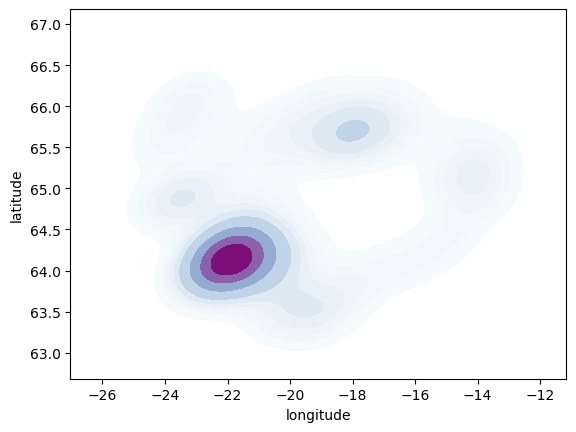

In [24]:
sns.kdeplot(
    x=tripadvisor_attractions_cleaned_df["longitude"], 
    y=tripadvisor_attractions_cleaned_df["latitude"], 
    n_levels=10, 
    fill=True, 
    cmap='BuPu',
    bw_adjust = 1
);

## DB Scan

In [25]:
## Express points in metres
# Convert lon/lat into Point objects + set CRS
pts = gpd.points_from_xy(
    tripadvisor_attractions_cleaned_df["longitude"],
    tripadvisor_attractions_cleaned_df["latitude"],
    crs="EPSG:4326"
)
# Convert lon/lat points to Icelandic CRS in metres
pts = gpd.GeoDataFrame({"geometry": pts}).to_crs(epsg=3057)

# Extract coordinates from point objects into columns
tripadvisor_attractions_cleaned_df["X_metres"] = pts.geometry.x
tripadvisor_attractions_cleaned_df["Y_metres"] = pts.geometry.y

In [26]:
weights = tripadvisor_attractions_cleaned_df['review_count']

db = DBSCAN(eps=1000, min_samples=4000).fit(
    tripadvisor_attractions_cleaned_df[['X_metres', 'Y_metres']], 
    sample_weight=weights
)

tripadvisor_attractions_cleaned_df['lbls'] = db.labels_

In [27]:
# Print only the first five values
db.core_sample_indices_[:5]

array([0, 1, 2, 3, 4])

In [28]:
lbls = pd.Series(db.labels_, index=tripadvisor_attractions_cleaned_df.index)
lbls

0      0
1      0
2      1
3      2
4      3
      ..
950   -1
951    0
952    0
953   -1
954   -1
Length: 955, dtype: int64

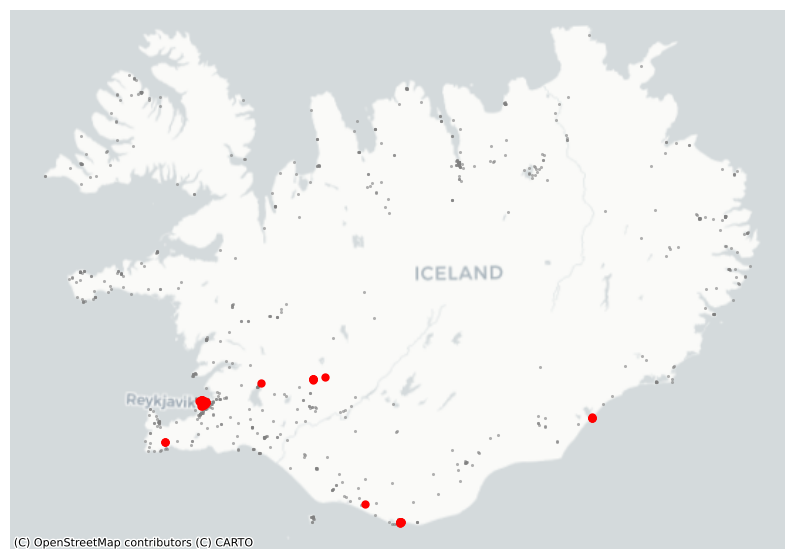

In [29]:
# Setup figure and axis
f, ax = plt.subplots(1, figsize=(10, 7))

# Assign labels dynamically and subset points that are not part of any cluster (noise)
noise = tripadvisor_attractions_cleaned_df.assign(
    lbls=lbls
).query("lbls == -1")

# Plot noise in grey
ax.scatter(
    noise["X_metres"], 
    noise["Y_metres"], 
    c='grey',
    alpha=0.6,
    s=5, 
    linewidth=0
)

# Plot all points that are not noise in red
ax.scatter(
    tripadvisor_attractions_cleaned_df.loc[tripadvisor_attractions_cleaned_df.index.difference(noise.index), "X_metres"], 
    tripadvisor_attractions_cleaned_df.loc[tripadvisor_attractions_cleaned_df.index.difference(noise.index), "Y_metres"],
    c="red", 
    linewidth=0
)


# add basemap
# Change 'crs' to the specific EPSG code for Iceland
cx.add_basemap(ax, crs="EPSG:3057", source=cx.providers.CartoDB.Positron)

ax.set_axis_off()
plt.show()

### Exploring the Review Count Attribute

In [30]:
# top 20 rows with the most review counts
top_20_attractions = tripadvisor_attractions_cleaned_df.nlargest(20, 'review_count')

In [31]:
# top_20_attractions

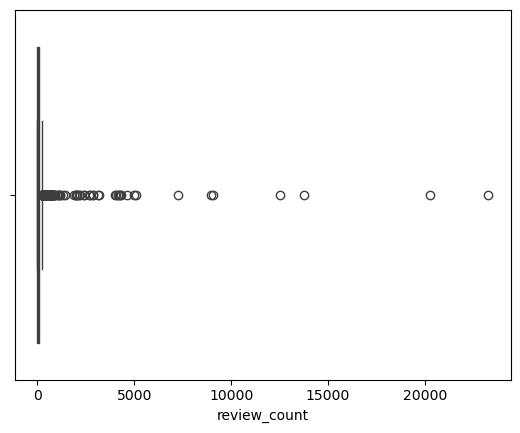

In [32]:
sns.boxplot(x=tripadvisor_attractions_cleaned_df['review_count'])
plt.show()

In [33]:
len(tripadvisor_attractions_cleaned_df[tripadvisor_attractions_cleaned_df['review_count'] > 1000])

37

In [34]:
len(tripadvisor_attractions_cleaned_df)

955

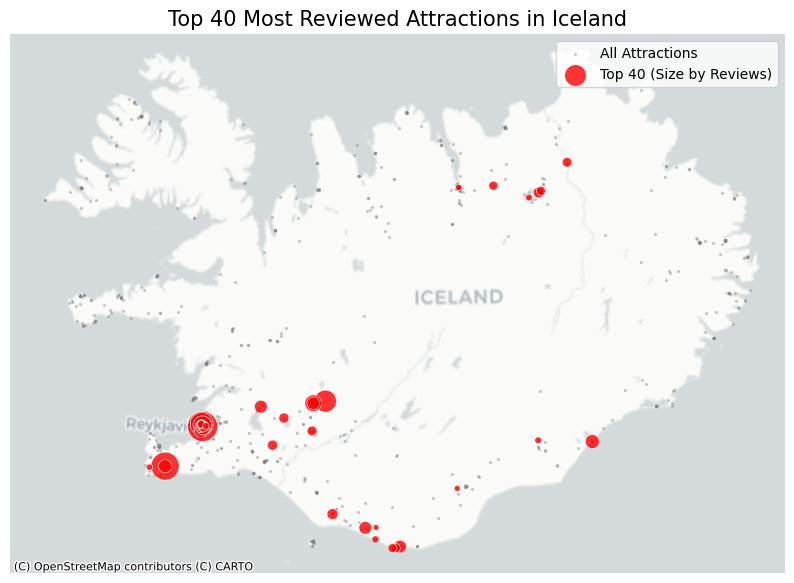

In [35]:
# top 40 attractions with base map

# 1. Get the top 40
top_40 = tripadvisor_attractions_cleaned_df.nlargest(40, 'review_count')

# 2. Setup figure
f, ax = plt.subplots(1, figsize=(10, 7))

# 3. Plot all attractions as small, faint grey dots for context
ax.scatter(
    tripadvisor_attractions_cleaned_df["X_metres"], 
    tripadvisor_attractions_cleaned_df["Y_metres"], 
    c='grey', alpha=0.3, s=2, label='All Attractions'
)

# 4. Plot the Top 40 as large, bright red dots
# 's' scales the size of the bubble by the review count (divided by 50 to keep it manageable)
ax.scatter(
    top_40["X_metres"], 
    top_40["Y_metres"], 
    c='red', 
    edgecolor='white', 
    linewidth=0.5,
    s=top_40['review_count'] / 50, 
    alpha=0.8,
    label='Top 40 (Size by Reviews)'
)

# 5. Add the Basemap (using the Icelandic CRS we established)
cx.add_basemap(ax, crs="EPSG:3057", source=cx.providers.CartoDB.Positron)

# 6. Formatting
ax.set_title("Top 40 Most Reviewed Attractions in Iceland", fontsize=15)
ax.set_axis_off()
plt.legend(loc='upper right')
plt.show()

In [36]:
tripadvisor_attractions_cleaned_export_df = tripadvisor_attractions_cleaned_df.copy()
tripadvisor_attractions_cleaned_export_df['category'] = tripadvisor_attractions_cleaned_export_df['category'].apply(lambda x: ' • '.join(x) if x else None)
tripadvisor_attractions_cleaned_export_df.to_file('tripadvisor_attractions_geo_cleaned.geojson', driver='GeoJSON')
print("Saved!")

Saved!


As I have made some important changes in this notebook, such as the removal of duplicates, I will save the dataframe again as json to be used in the routing.